# `multiplicity` — predicting particle count from a pixel pattern

A real (non-truth) splitter needs to know *whether* a cluster should be
split, and into how many pieces, before it can decide *how*. `multiplicity`
is a small MLP that predicts a cluster's particle multiplicity (1, 2, or 3)
from its pixel-charge pattern alone — trained on `sensor`-shaped run
directories, exactly like `splitting` consumes.

**Model**: a fixed-size `(N, M)` pixel-charge matrix per cluster (`N`/`M`
derived from the training data's largest cluster span, not hardcoded) feeds
`Flatten -> Linear(N*M,32) -> ReLU -> Linear(32,32) -> ReLU -> Linear(32,1)
-> Sigmoid`. Particle counts have a natural order (1 < 2 < 3), so this is
trained as **ordinal regression** (MSE against an equally-spaced target: 1
particle -> 0.0, 2 -> 0.5, 3 -> 1.0), not a 3-way softmax classifier, and
decoded back into a class via 3 equal-width score bins.


In [1]:
%matplotlib inline
import os
import tempfile
import matplotlib.pyplot as plt

from sensor.sim import load_config as load_sensor_config
from sensor.cli import run_simulation
from sensor.io import write_run as write_sensor_run

from multiplicity.train import train_model, save_checkpoint, load_checkpoint
from multiplicity.evaluate import evaluate_model, plot_roc, plot_confusion_matrix


## Building single-multiplicity training directories

`configs/p1.yaml`/`p2.yaml`/`p3.yaml` are identical except for
`multi.n_particles` (fixed at 1, 2, 3 respectively). Training pools every
cluster from all directories passed in — this is what lets the same `train`
command work equally well on three single-multiplicity directories or one
already-mixed one.


In [2]:
run_dir = tempfile.mkdtemp()
train_dirs = {}
for name, seed in [("p1", 1), ("p2", 2), ("p3", 3)]:
    config = load_sensor_config(f"../aihep/clustering/sensor/configs/{name}.yaml")
    config.n_events = 500
    config.seed = seed
    hits, clusters, truth, contributions = run_simulation(config)
    path = os.path.join(run_dir, name)
    write_sensor_run(path, "arrow", hits, clusters, truth, contributions)
    train_dirs[name] = path
    print(f"{name}: {len(hits)} hit pixels, {len(clusters)} clusters")


p1: 28418 hit pixels, 27527 clusters
p2: 29854 hit pixels, 27395 clusters
p3: 30444 hit pixels, 27261 clusters


## Training

Only clusters with **at least one contributing truth particle** count as
training examples — the large majority of clusters in `p1`/`p2`/`p3` are
single- or few-pixel digitization noise, and those are excluded.
`train_model` derives and returns `matrix_shape` from this training data;
it must be reused for any later, independent evaluation set so clusters are
embedded identically.


epoch   1/50  train_loss=0.1657  val_loss=0.1649  val_acc=0.333
epoch   2/50  train_loss=0.1643  val_loss=0.1636  val_acc=0.333
epoch   3/50  train_loss=0.1629  val_loss=0.1620  val_acc=0.333
epoch   4/50  train_loss=0.1612  val_loss=0.1602  val_acc=0.333
epoch   5/50  train_loss=0.1593  val_loss=0.1579  val_acc=0.333
epoch   6/50  train_loss=0.1569  val_loss=0.1552  val_acc=0.333
epoch   7/50  train_loss=0.1538  val_loss=0.1516  val_acc=0.333
epoch   8/50  train_loss=0.1499  val_loss=0.1472  val_acc=0.333
epoch   9/50  train_loss=0.1451  val_loss=0.1419  val_acc=0.333
epoch  10/50  train_loss=0.1394  val_loss=0.1355  val_acc=0.338
epoch  11/50  train_loss=0.1325  val_loss=0.1283  val_acc=0.387
epoch  12/50  train_loss=0.1251  val_loss=0.1206  val_acc=0.476
epoch  13/50  train_loss=0.1171  val_loss=0.1127  val_acc=0.520
epoch  14/50  train_loss=0.1092  val_loss=0.1047  val_acc=0.556
epoch  15/50  train_loss=0.1011  val_loss=0.0970  val_acc=0.547
epoch  16/50  train_loss=0.0933  val_los

Text(0.5, 1.0, 'final val accuracy: 98.7%')

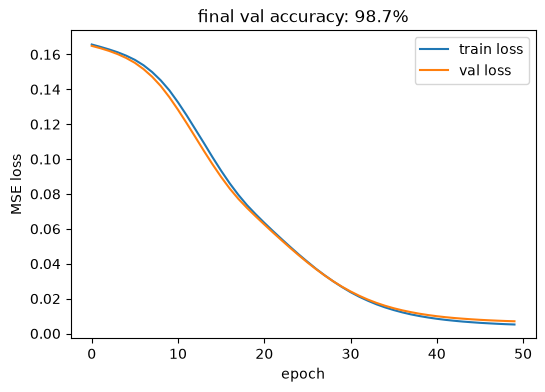

In [3]:
model, matrix_shape, history = train_model(
    list(train_dirs.values()), fmt="arrow", epochs=50, seed=0,
)
print("input matrix shape:", matrix_shape)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history.train_loss, label="train loss")
ax.plot(history.val_loss, label="val loss")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE loss")
ax.legend()
ax.set_title(f"final val accuracy: {history.val_accuracy[-1]:.1%}")


## Evaluating on a genuinely independent set

`configs/p123.yaml` mixes 1-3 particles per event (uniform) with a
*different* seed — a run the model never trained on. The checkpoint's own
`matrix_shape` is reloaded and reused so this set is embedded identically
to training.


In [4]:
ckpt_path = os.path.join(run_dir, "model.pt")
save_checkpoint(ckpt_path, model, matrix_shape)
model, matrix_shape = load_checkpoint(ckpt_path)

eval_config = load_sensor_config("../aihep/clustering/sensor/configs/p123.yaml")
eval_config.n_events = 300
eval_config.seed = 999
hits, clusters, truth, contributions = run_simulation(eval_config)
eval_dir = os.path.join(run_dir, "p123")
write_sensor_run(eval_dir, "arrow", hits, clusters, truth, contributions)

result = evaluate_model(model, matrix_shape, [eval_dir], fmt="arrow")
print(f"accuracy: {result['accuracy']:.1%}")


accuracy: 98.0%


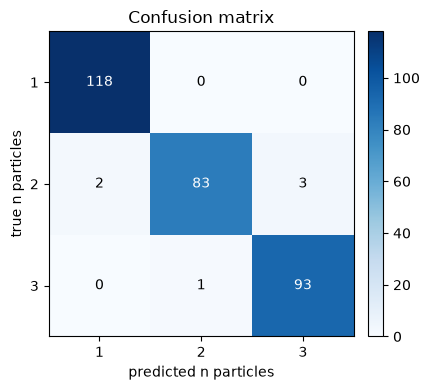

In [5]:
fig = plot_confusion_matrix(result["confusion_matrix"], result["classes"])


## ROC curves

Ranking score per class is derived from the single ordinal output: class 3
ranks directly on the raw score, class 1 on the inverted score, and class 2
(bounded on both sides) on proximity to its own target value — the natural
generalization of "higher score = more particles" to a middle class.


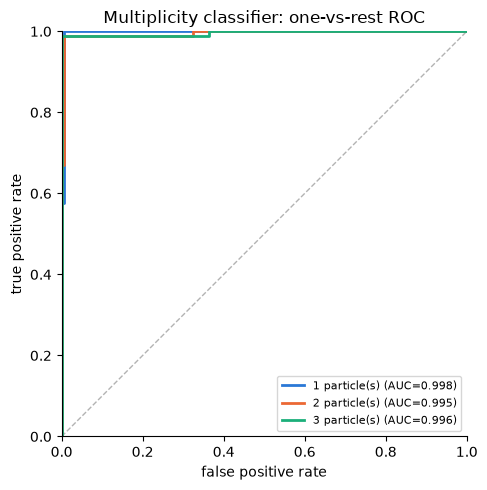

In [6]:
fig = plot_roc(result["roc"])
